### import

In [15]:
import numpy as np
import os
import sys
import json
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import enchant
import time
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.preprocessing import Normalizer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import NMF, LatentDirichletAllocation

### Parameters

In [2]:
min_count = 100
max_frequency = 0.001

### Find All Files in Test and Train

In [3]:
test_data = favorite_color = pickle.load( open( "../../data/20newsgroups/pickle/test_clean.p", "rb"))
train_data = favorite_color = pickle.load( open( "../../data/20newsgroups/pickle/train_clean.p", "rb"))
test_corpus = test_data['corpus']
test_categories = test_data['category']
train_corpus = train_data['corpus']
train_categories = train_data['category']

### Word Count

In [4]:
D = {}
for i in range(len(test_corpus)):
    text = test_corpus[i]
    words = text.split(' ') 
    for word in words:
        if word in D:
            count = D[word]
            D[word] = count + 1
        else:
            D[word] = 1
print(len(D))

101640


### Get rid of words that contain digits, are only 2 letters long or 3 letter words that are not in the dictionary

In [5]:
english = enchant.Dict("en_US")
remove_list = []
for word in D:
    if any(ch.isdigit() for ch in word):
        remove_list.append(word)
    if (len(word) < 3):
        remove_list.append(word)
    if (len(word) == 3 and english.check(word) == False):
        remove_list.append(word)
remove_list = list(set(remove_list))
for word in remove_list:
    D.pop(word)
print(len(D))    

68596


### Extract Counts

In [6]:
counts = np.array(list(D.values()))
frequencies = counts / np.sum(counts)
keywords = np.array(list(D.keys()))
indices = np.argsort(frequencies)[::-1]
frequencies = frequencies[indices]
counts = counts[indices]
keywords = keywords[indices]
print(len(keywords))

68596


### Remove low count (rare) words

2742


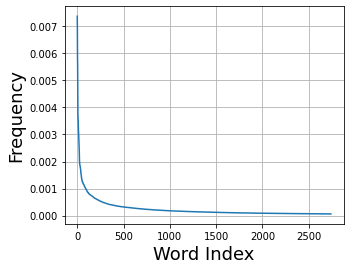

In [7]:
indices = np.where(counts > min_count)[0]
keywords = keywords[indices]
frequencies = frequencies[indices]
counts = counts[indices]
plt.figure(figsize=(5,4));
plt.plot(frequencies);
plt.grid();
plt.xlabel('Word Index',fontsize=18);
plt.ylabel('Frequency',fontsize=18);
print(len(keywords))

### Remove too frequent words

2651


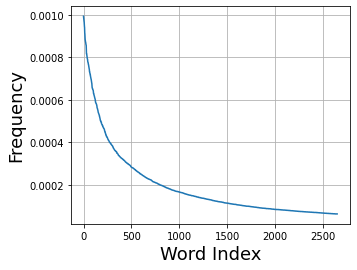

In [8]:
indices = np.where(frequencies < max_frequency)[0]
keywords = keywords[indices]
frequencies = frequencies[indices]
counts = counts[indices]
plt.figure(figsize=(5,4));
plt.plot(frequencies);
plt.grid();
plt.xlabel('Word Index',fontsize=18);
plt.ylabel('Frequency',fontsize=18);
print(len(keywords))

### Create Look Up Table and Empty Matrix

In [9]:
LUT = {}
for k,keyword in enumerate(keywords):
    LUT[keyword] = k

### Compute Term Frequency

In [10]:
count = 0
TF = np.zeros((len(test_corpus),len(keywords)))
for row in tqdm(range(len(test_corpus))):
    text = test_corpus[row]
    words = text.split(' ')
    for word in words:
        if word in keywords:
            if word == 'friends':
                count = count + 1
            column = LUT[word]
            TF[row,column] = TF[row,column] + 1

100%|███████████████████████████████████████████████████████████████████████| 11275/11275 [00:55<00:00, 204.13it/s]


### Fit LDA

In [23]:
no_topics = 10
lda = LatentDirichletAllocation(
    n_components=no_topics,
    max_iter=5,
    learning_method="online",
    learning_offset=50.0,
    random_state=0)
lda.fit(TF)

### Plot Topic Strength across words of Topic 1

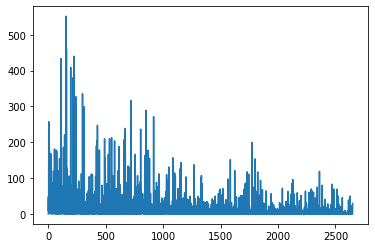

In [29]:
C = lda.components_
plt.plot(C[0,:]);

### LDA Topics

In [32]:
topics = []
columns = []
no_topic_keywords = 10
for idx in range(no_topics):
    ind = np.argsort(C[idx,:])[-no_topic_keywords:]
    columns.append('topic ' + str(idx+1))
    topic = []
    for keyword in keywords[ind]:
        topic.append(keyword)
    topics.append(topic)
topics = np.array(topics)
topics = topics.T
topics = pd.DataFrame(topics)
topics.columns = columns
topics

,topic 1,topic 2,topic 3,topic 4,topic 5,topic 6,topic 7,topic 8,topic 9,topic 10
0,jewish,soviet,evidence,left,inc,ftp,police,paul,baseball,algorithm
1,stephanopoulos,army,fact,come,bill,graphics,control,christ,league,technology
2,israeli,men,wrong,put,phone,bit,firearms,book,players,colorado
3,clinton,women,rather,went,canada,version,crime,science,season,keys
4,states,children,however,long,email,files,house,earth,hockey,security
5,rights,russian,reason,thing,looking,dos,federal,nasa,win,encryption
6,israel,april,mean,little,buy,scsi,public,church,play,clipper
7,war,armenians,truth,car,price,window,guns,christian,games,public
8,president,armenian,life,around,card,available,law,bible,team,law
9,jews,turkish,true,day,sale,software,gun,jesus,game,chip
